In [1]:
import os
from pathlib import Path

In [2]:
%pwd

'd:\\Projects\\ViT_from_scratch\\research'

In [3]:
os.chdir("../")

In [4]:
%pwd

'd:\\Projects\\ViT_from_scratch'

In [5]:
import random
import matplotlib.pyplot as plt
import torch
import numpy as np

In [30]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device 

'cuda'

In [31]:
# test dataset 
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from src.vision_Transformer.logging import logger
import matplotlib.pyplot as plt
import torchvision.datasets as datasets

after_transforms = transforms.Compose([
            transforms.RandomCrop(32 , padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.2 ,contrast= 0.2, saturation=0.2 , hue=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3 , std = [0.5]*3)
])
train_dataset = datasets.CIFAR10(
            root= "test",
            train = True,
            download = True,
            transform = after_transforms,
        )
test_dataset = datasets.CIFAR10(
            root= "test",
            train = False,
            download = True,
            transform = after_transforms,
        )

In [32]:
len(test_dataset) , len(train_dataset) , len(train_dataset.classes)

(10000, 50000, 10)

In [33]:
from src.vision_Transformer.Components.ViT_Component.Vision_Transformer_Class import Vision_Transformer_Class
from src.vision_Transformer.Components.ViT_Component.Transformer_EncoderLayer import Transformer_Encoder_Layer
from src.vision_Transformer.Components.ViT_Component.Patch_Embedding import PatchEmbedding
from src.vision_Transformer.Components.ViT_Component.MLP import MLP


def load_model(full_model_path):
    full_model = torch.load(full_model_path , weights_only=False)

    # state_dict = torch.load(state_dict_model_path)
    # state_model = 
    print(f"full Model loaded successfully ----------------------")
    return full_model

In [34]:
def predict_plot_grid(model , dataset , classes , grid_size):
  model.eval()

  

  fig , axes = plt.subplots(grid_size , grid_size , figsize = (9 , 9))
  for i in range(grid_size):
    for j in range(grid_size):
      idx = random.randint(0 , len(dataset) - 1)
      img , true_label = dataset[idx]
      input_tensor = img.unsqueeze(0).to(device)

      with torch.inference_mode():
        output = model(input_tensor)

        _ , predicted = torch.max(output.data , 1)

      img = img / 2 + 0.5 # Unormalize our images to be able to plot them with matplotlib
      numpy_img = img.cpu().numpy() # numpy expects the image on cpu
      axes[i , j].imshow(np.transpose(numpy_img , (1 , 2 ,0)))

      truth = classes[true_label] == classes[predicted.item()]
      if truth:
        color = "g"
      else:
        color = "r"

      axes[i, j].set_title(f"Truth: {classes[true_label]}\n, Predicted: {classes[predicted.item()]}", fontsize=10, c=color)
      axes[i, j].axis("off")
  plt.tight_layout()
  plt.show()


full Model loaded successfully ----------------------


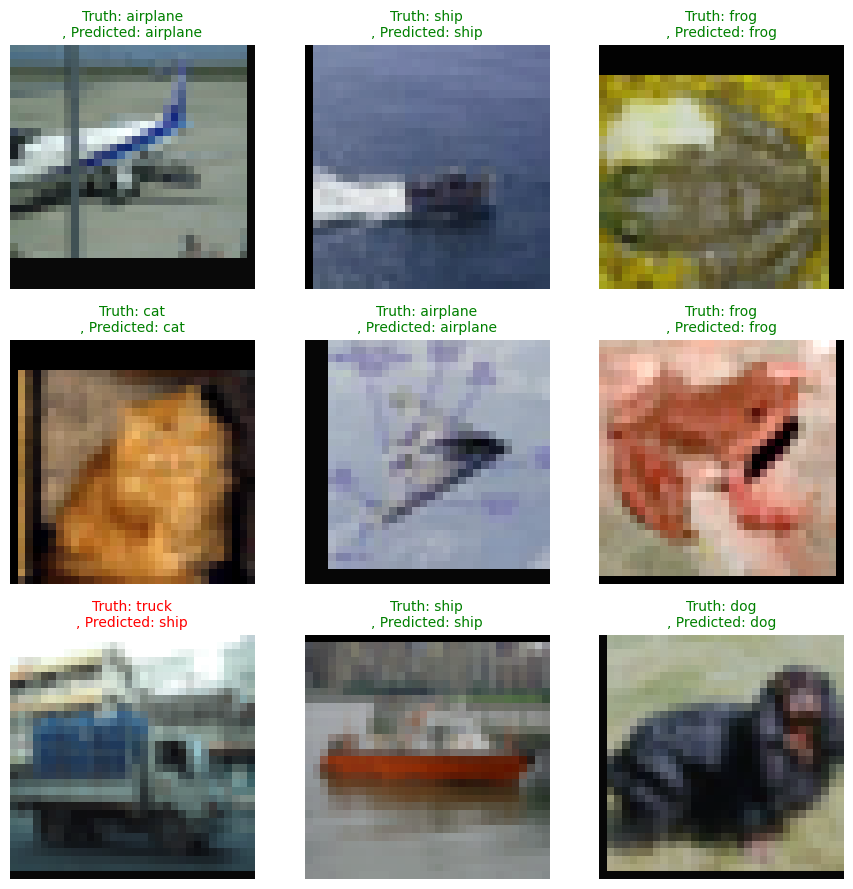

In [36]:
full_model_file_path = 'model\complete_model.pth'
model = load_model(full_model_file_path)


predict_plot_grid(model , test_dataset , train_dataset.classes , 3)
